In [19]:
import numpy as np

import h5py as h5

import matplotlib.pyplot as plt

from sam2.addons import show_anns

from PIL import Image

import torch
import torch.nn.functional as F

# ---------------------------
# Device (MPS preferred)
# ---------------------------
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()
DTYPE  = torch.float32

## Load Data

Each dataset is stored as an `*.h5` file with the following structure:

```text
├── image                 # Original image [x, y], dtype=uint8
├── labels                # Instance label map [x, y], dtype=uint32
├── mask                  # Binary mask of the roving region [x, y], dtype=bool
└── instances/            # Group containing per-instance annotations
    ├── <instance_id>/    # e.g., 0001, 0002, ...
    │   ├── id                    # Integer ID
    │   ├── area                  # Segmented area (float)
    │   ├── bbox                  # Bounding box [x0, y0, w, h]
    │   └── segmentation_cropped  # Cropped mask [w, h], dtype=bool

In [7]:
sample = {}

with h5.File("160_00_01_50x.h5", "r") as F:
    # Load top-level datasets
    sample["image"] = np.array(F["image"])
    sample["labels"] = np.array(F["labels"])
    sample["mask"] = np.array(F["mask"])
    # Load instance information
    instances = []
    if "instances" in F:
        group = F["instances"]
        for key in group.keys():
            inst = group[key]
            instance_dict = {
                "id": int(inst["id"][()]),
                "area": float(inst["area"][()]),
                "bbox": np.array(inst["bbox"]),
                "segmentation_crop": np.array(inst["segmentation_crop"])
            }
            instances.append(instance_dict)
    sample["instances"] = instances

## Display the Data

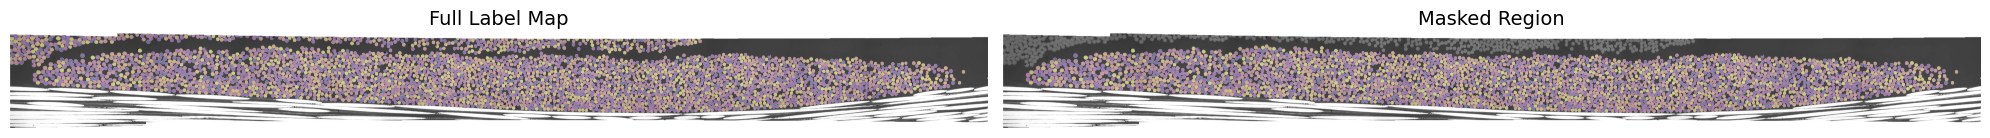

In [13]:
# --- Generate overlays ---
label_map = show_anns(
    instances,
    borders=False,
    alpha=0.35,
    canvas_shape=sample["image"].shape[:2]
)

# Apply mask transparency
masked_rgba = label_map.copy()
m = np.asarray(sample["mask"]).astype(bool)
assert m.shape == masked_rgba.shape[:2]

masked_rgba[~m, :3] = 0.0  # make outside mask transparent

# --- Plot side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: original with all instances
axes[0].imshow(sample["image"], cmap="gray")
axes[0].imshow(label_map)
axes[0].set_title("Full Label Map", fontsize=14)
axes[0].axis("off")

# Right: masked region only
axes[1].imshow(sample["image"], cmap="gray")
axes[1].imshow(masked_rgba)
axes[1].set_title("Masked Region", fontsize=14)
axes[1].axis("off")

plt.tight_layout()

## Analysis

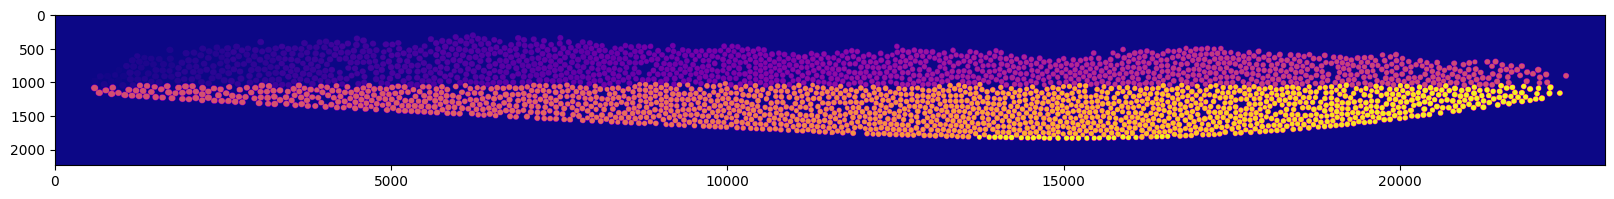

In [18]:
labels = sample["labels"].copy()  # keep original safe


labels[~m] = 0  # set labels outside mask to 0 (or np.nan if float)
plt.figure(figsize=(20,10))
plt.imshow(labels,cmap="plasma")
plt.show()

In [31]:
def patch_torch(input, patch_size, stride, padding="same", device=None):
    """
    Extract square patches from a 2D label map as a tensor [N, patch_size, patch_size].

    Parameters
    ----------
    input : np.ndarray or torch.Tensor
        2D label map (H, W), integer or float values.
    patch_size : int
        Size of the square patch (height = width).
    stride : int
        Step between patch centers.
    padding : str or int, optional
        'same'  → pads evenly so patches cover full image
        'valid' → no padding (only full patches)
        int     → explicit padding value (pixels)
    device : torch.device, optional
        Device to use ('mps', 'cuda', or 'cpu'). Defaults to same as input tensor.

    Returns
    -------
    patches : torch.Tensor
        Tensor of shape [N, patch_size, patch_size].
    coords : list[(y, x)]
        List of top-left pixel coordinates for each patch in the original (unpadded) map.
    padded_shape : (H_padded, W_padded)
        Shape after padding.
    """
    # convert input
    if not isinstance(input, torch.Tensor):
        x = torch.as_tensor(input)
    else:
        x = input
    x = x.to(torch.float32)

    if x.ndim != 2:
        raise ValueError("label_map must be 2D")

    if device is None:
        device = x.device
    x = x.unsqueeze(0).unsqueeze(0).to(device)  # [1,1,H,W]

    H, W = x.shape[-2:]
    p = patch_size

    # Determine padding
    if isinstance(padding, str):
        if padding.lower() == "same":
            pad_h = (stride - (H - p) % stride) % stride if H >= p else (p - H)
            pad_w = (stride - (W - p) % stride) % stride if W >= p else (p - W)
        elif padding.lower() == "valid":
            pad_h = pad_w = 0
        else:
            raise ValueError("padding must be 'same', 'valid', or int")
    else:
        pad_h = pad_w = int(padding)

    # Pad symmetrically (bottom/right if needed)
    x_pad = F.pad(x, (0, pad_w, 0, pad_h), mode="constant", value=0)
    Hp, Wp = x_pad.shape[-2:]

    # Extract patches
    unfold = torch.nn.Unfold(kernel_size=(p, p), stride=stride)
    cols = unfold(x_pad)               # [1, p*p, L]
    L = cols.shape[-1]
    patches = cols.transpose(1, 2).reshape(L, p, p)  # [L, p, p]

    # Compute coordinates of top-left corners
    ys = range(0, Hp - p + 1, stride)
    xs = range(0, Wp - p + 1, stride)
    coords = [(y, x) for y in ys for x in xs]

    return patches, coords, (Hp, Wp)

def filter_patches_by_coverage(patches, coords, min_frac=0.6):
    """
    Keep patches with at least `min_frac` of non-zero labels.

    Parameters
    ----------
    patches : torch.Tensor  # [N, p, p]
        Label patches.
    coords  : list[(y,x)]
        Top-left coords for each patch (same order as `patches`).
    min_frac : float
        Minimum fraction of labeled pixels (labels > 0).

    Returns
    -------
    patches_kept : torch.Tensor   # [K, p, p]
    coords_kept  : list[(y,x)]    # len K
    keep_mask    : torch.BoolTensor  # [N]
    coverage     : torch.Tensor   # [N] fraction per patch (for inspection)
    """
    # fraction of labeled pixels per patch
    coverage = (patches > 0).float().mean(dim=(1, 2))
    keep_mask = coverage >= float(min_frac)

    patches_kept = patches[keep_mask]
    coords_kept  = [c for c, k in zip(coords, keep_mask.tolist()) if k]
    return patches_kept, coords_kept, keep_mask, coverage


from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

def plot_patch_bboxes(image, coords, patch_size, color="lime", lw=1.5, alpha=0.9):
    """
    Draw bounding boxes for kept patches on top of the original image.

    Parameters
    ----------
    image : np.ndarray
        Original image (H, W) or (H, W, 3).
    coords : list[(y, x)]
        Top-left coordinates for each kept patch (from extract/filter step).
    patch_size : int
        Square patch size used when extracting patches.
    color : str
        Edge color of rectangles.
    lw : float
        Line width.
    alpha : float
        Alpha of rectangle edges.
    """
    H, W = image.shape[:2]
    rects = []

    for (y, x) in coords:
        x0 = max(0, min(W, x))
        y0 = max(0, min(H, y))
        x1 = max(0, min(W, x + patch_size))
        y1 = max(0, min(H, y + patch_size))
        if x1 <= x0 or y1 <= y0:   # fully outside after clipping
            continue
        rects.append(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False))

    fig, ax = plt.subplots(figsize=(20, 10))
    if image.ndim == 2:
        ax.imshow(image, cmap="gray")
    else:
        ax.imshow(image)
    if rects:
        pc = PatchCollection(rects, facecolor="none", edgecolor=color, linewidths=lw, alpha=alpha)
        ax.add_collection(pc)
    ax.set_title(f"Kept patches: {len(rects)}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

Kept 1375 / 2864 patches


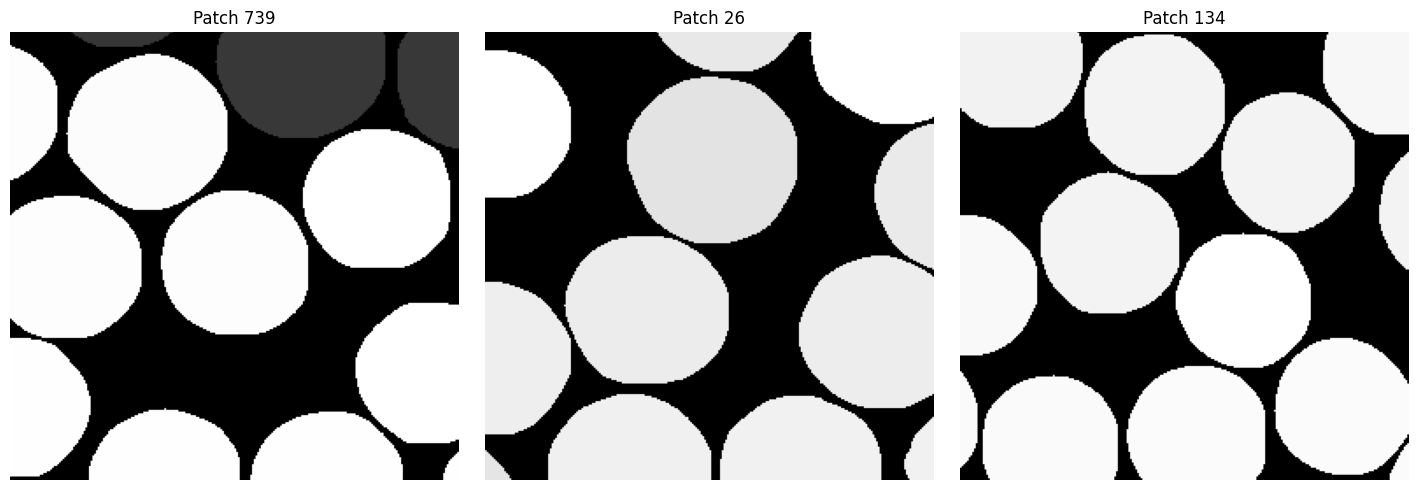

In [60]:
size = 256
stride = size//2

patches, coords, padded_shape = patch_torch(
    labels, patch_size=size, stride=stride, padding="valid", device="mps"
)

patches_kept, coords_kept, keep_mask, coverage = filter_patches_by_coverage(patches, coords, min_frac=0.4)

print(f"Kept {len(patches_kept)} / {len(patches)} patches")

fig, axs = plt.subplots(1,3,figsize=(3*4.8,4.8))

for i in range(3):
    # pick a random patch index
    i_random = np.random.randint(0, len(patches_kept))

    axs[i].imshow(patches_kept[i_random].cpu().numpy(), cmap="gray")
    axs[i].set_title(f"Patch {i_random}")
    axs[i].axis("off")

plt.tight_layout()
plt.show()

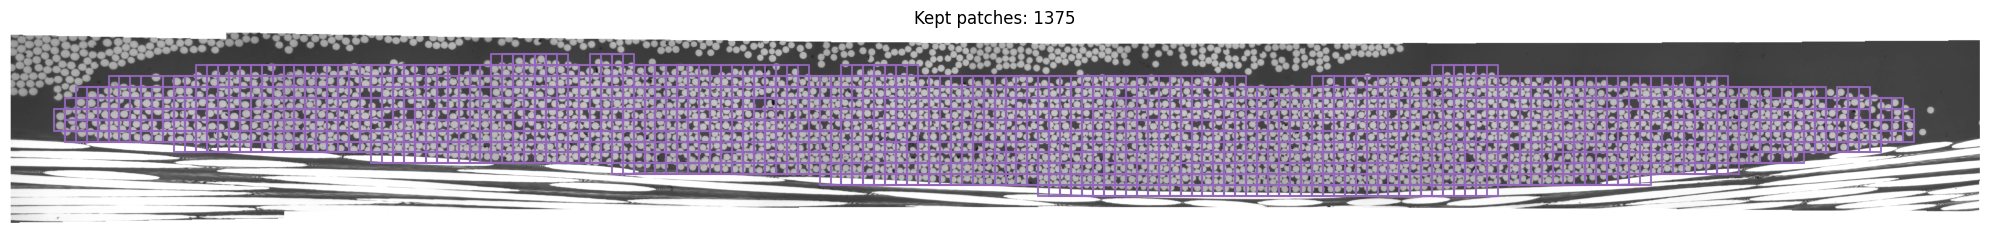

In [61]:
plot_patch_bboxes(sample["image"], coords_kept, patch_size=size, color="tab:purple", lw=1.5)

## Spatial Estimation of the statistical RVE size

torch.Size([1375, 256, 256]) torch.float32 mps:0


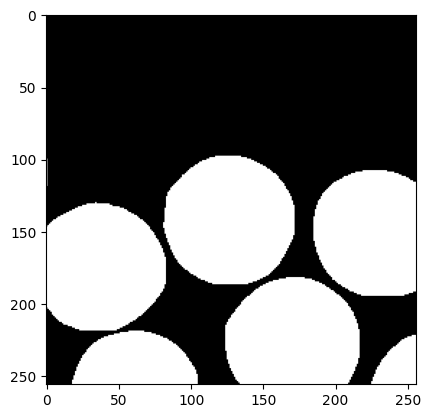

In [62]:


# binarize: > 0  → 1.0 , else 0.0
patches_tensor = (patches_kept > 0).float() # binary as float

print(patches_tensor.shape, patches_tensor.dtype, patches_tensor.device)
plt.imshow(patches_tensor[0,::].cpu().numpy(),cmap="gray")
plt.show()

## Helper Functions for Analysis


Using descriptors for estimation of 




In [63]:
def s2_descriptor(patches: torch.Tensor, radial: bool = False, eps: float = 1e-12):
    """
    Compute two-point correlation S2 for binary patches.

    Parameters
    ----------
    patches : torch.Tensor
        Shape [B, H, W], values in {0,1} (float/bool is fine). On CPU/GPU/MPS.

    Returns
    -------
    result : dict
        - 'S2':   (B,H,W)      centered two-point correlation
    """
    assert patches.ndim == 3, "Expected [B,H,W]"
    x = patches.to(torch.float32)

    B, H, W = x.shape


    # ---- S2 via FFT (autocorrelation normalized by N) ----
    F = torch.fft.fft2(x, dim=(-2, -1))
    S2 = torch.real(torch.fft.ifft2(F * torch.conj(F), dim=(-2, -1))) / (H * W)
    S2 = torch.fft.fftshift(S2, dim=(-2, -1))  # center
    
    if radial:
        # Precompute radius bins (shared for batch)
        device = x.device
        y = torch.arange(H, device=device)
        z = torch.arange(W, device=device)
        yy, zz = torch.meshgrid(y, z, indexing="ij")
        cy, cz = (H - 1) / 2.0, (W - 1) / 2.0
        r = torch.sqrt((yy - cy) ** 2 + (zz - cz) ** 2)
        r_int = r.round().to(torch.int64)
        rmax = int(r_int.max().item())

        vals = S2.reshape(B, -1)
        bins = r_int.reshape(-1)
        prof = torch.zeros((B, rmax + 1), device=device, dtype=vals.dtype)
        prof.scatter_add_(1, bins.unsqueeze(0).expand(B, -1), vals)

        # counts per radius
        cnt = torch.zeros(rmax + 1, device=device, dtype=vals.dtype)
        cnt.scatter_add_(0, bins, torch.ones_like(bins, dtype=vals.dtype, device=device))
        prof = prof / torch.clamp(cnt, min=eps)

        return S2, prof  # (B, R)
    
    return S2

def phi_descriptor(patches: torch.Tensor, eps: float = 1e-12):
    """
    Compute volume fraction (phi) for binary patches.

    Parameters
    ----------
    patches : torch.Tensor
        Shape [B, H, W], values in {0,1} (float/bool is fine). On CPU/GPU/MPS.
    Returns
    -------
    result : dict
        - 'phi':  (B,)         volume fraction
    """
    assert patches.ndim == 3, "Expected [B,H,W]"
    x = patches.to(torch.float32)

    B, H, W = x.shape

    # ---- phi ----
    phi = x.mean(dim=(1, 2))  # (B,)
    return phi

0.4051056
0.49110413
0.51748276
0.5576476


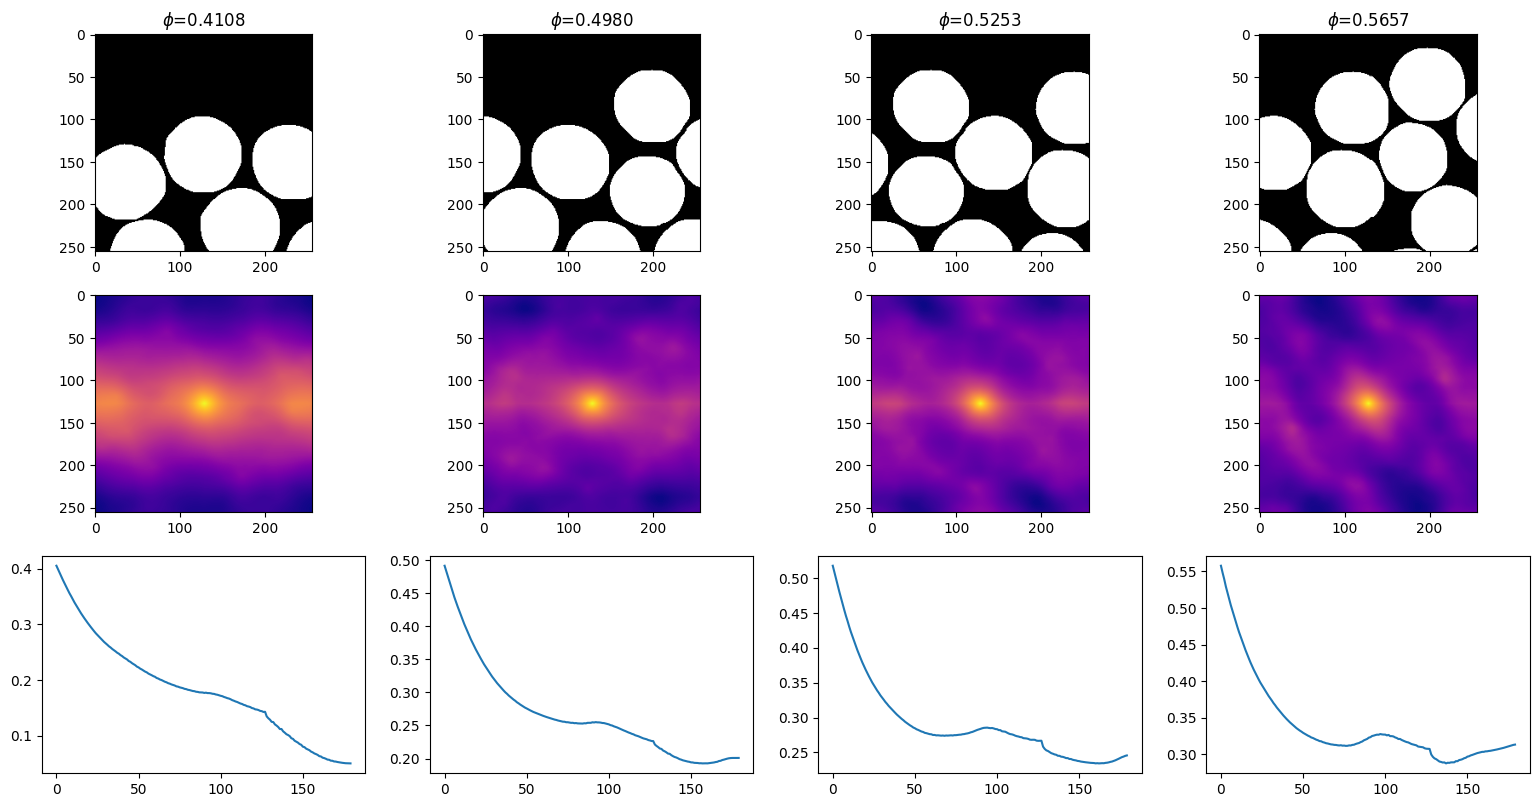

In [64]:
patches_S2, patches_S2r = s2_descriptor(patches_tensor,radial=True)
patches_phi = phi_descriptor(patches_tensor)


fig, axs = plt.subplots(3,4, figsize=(4*4.8,2*4.8))

for i in range(4):
    axs[0][i].imshow(patches_tensor[i,::].cpu().numpy(),cmap="gray")
    axs[0][i].set_title(f"$\phi$={patches_phi[i].cpu().numpy():.4f}")
    axs[1][i].imshow(patches_S2[i,::].cpu().numpy(),cmap="plasma")
    axs[2][i].plot(patches_S2r[i,1:].cpu().numpy())
    print(patches_S2r[i,1:].cpu().numpy().max())
